In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import librosa
import librosa.display

from IPython.display import Audio, display

from datasets import load_dataset, Audio as HFAudio

In [2]:
dataset = load_dataset(
    "urgent-challenge/urgent2025-sqa",
    split="blind_test_mos",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    HFAudio(decode=True)
)

sample = next(iter(dataset))

print("Sample ID:", sample["sample_id"])
print("System ID:", sample["system_id"])
print("Human MOS:", sample["mos"])

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Sample ID: urgent25_blind_test_fileid_000001
System ID: urgent25_blind_test_submission_716
Human MOS: 1.5


In [3]:
audio = sample["audio"]

waveform = audio.get_all_samples()

samples = waveform.data.numpy()
sample_rate = waveform.sample_rate

y_audio = samples.squeeze()

print("Waveform shape:", y_audio.shape)
print("Sampling rate:", sample_rate)

Waveform shape: (295158,)
Sampling rate: 48000


In [4]:
num_samples = len(y_audio)
duration = num_samples / sample_rate

print("Number of samples:", num_samples)
print("Sampling rate:", sample_rate, "Hz")
print("Duration:", round(duration, 2), "seconds")
print("Number of channels:", samples.shape[0] if samples.ndim > 1 else 1)

Number of samples: 295158
Sampling rate: 48000 Hz
Duration: 6.15 seconds
Number of channels: 1


In [5]:
display(
    Audio(
        y_audio,
        rate=sample_rate
    )
)

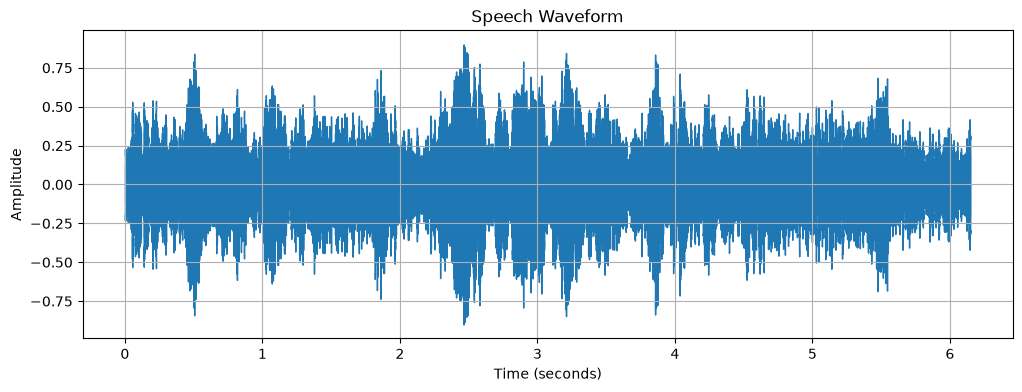

In [6]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    y_audio,
    sr=sample_rate
)

plt.title("Speech Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

In [7]:
print("Minimum amplitude:", np.min(y_audio))
print("Maximum amplitude:", np.max(y_audio))
print("Mean amplitude:", np.mean(y_audio))
print("Standard deviation:", np.std(y_audio))

Minimum amplitude: -0.8999939
Maximum amplitude: 0.8847351
Mean amplitude: -1.8819886e-05
Standard deviation: 0.1833121


In [8]:
rms = np.sqrt(
    np.mean(y_audio ** 2)
)

print("Overall RMS Energy:", rms)

Overall RMS Energy: 0.1833121


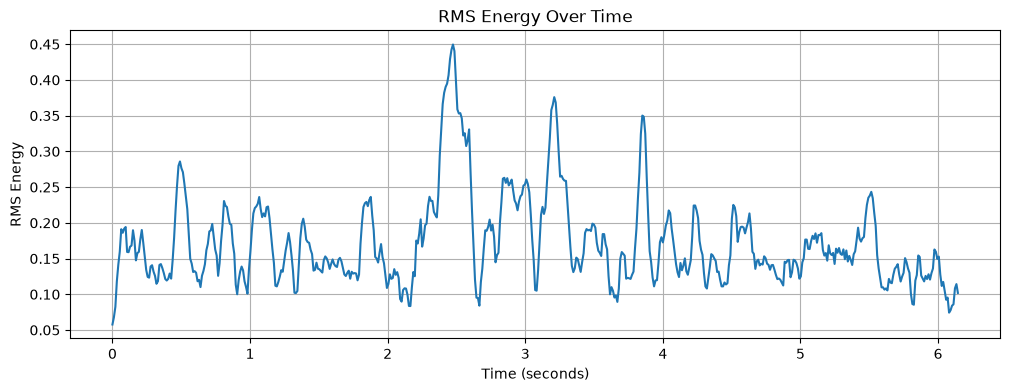

In [9]:
rms_frames = librosa.feature.rms(
    y=y_audio
)

rms_values = rms_frames.flatten()

times = librosa.frames_to_time(
    np.arange(len(rms_values)),
    sr=sample_rate
)

plt.figure(figsize=(12, 4))

plt.plot(
    times,
    rms_values
)

plt.title("RMS Energy Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")

plt.grid(True)
plt.show()

In [10]:
rms_features = {
    "rms_mean": np.mean(rms_values),
    "rms_std": np.std(rms_values),
    "rms_min": np.min(rms_values),
    "rms_max": np.max(rms_values),
    "rms_median": np.median(rms_values)
}

rms_features

{'rms_mean': np.float32(0.1719361),
 'rms_std': np.float32(0.06315059),
 'rms_min': np.float32(0.057730522),
 'rms_max': np.float32(0.449572),
 'rms_median': np.float32(0.15469588)}

In [11]:
zcr_frames = librosa.feature.zero_crossing_rate(
    y_audio
)

zcr_values = zcr_frames.flatten()

print("Mean ZCR:", np.mean(zcr_values))

Mean ZCR: 0.10017804917677643


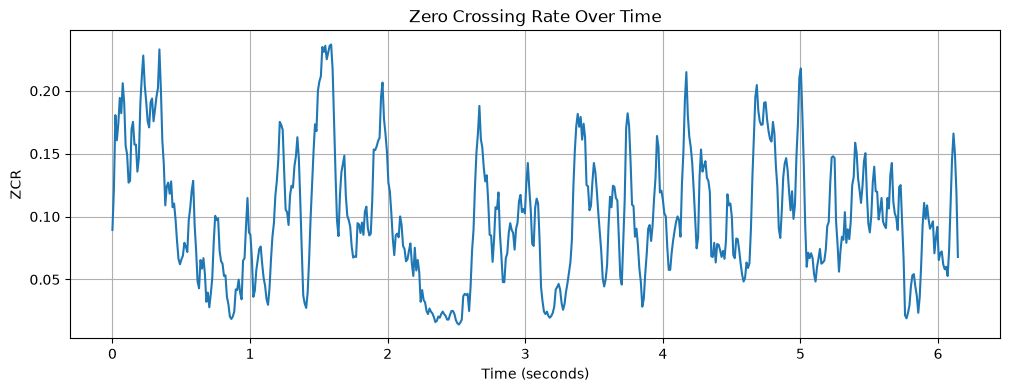

In [12]:
times = librosa.frames_to_time(
    np.arange(len(zcr_values)),
    sr=sample_rate
)

plt.figure(figsize=(12, 4))

plt.plot(
    times,
    zcr_values
)

plt.title("Zero Crossing Rate Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")

plt.grid(True)
plt.show()

In [13]:
zcr_features = {
    "zcr_mean": np.mean(zcr_values),
    "zcr_std": np.std(zcr_values),
    "zcr_min": np.min(zcr_values),
    "zcr_max": np.max(zcr_values),
    "zcr_median": np.median(zcr_values)
}

zcr_features

{'zcr_mean': np.float64(0.10017804917677643),
 'zcr_std': np.float64(0.050819021274258996),
 'zcr_min': np.float64(0.01416015625),
 'zcr_max': np.float64(0.23681640625),
 'zcr_median': np.float64(0.09423828125)}

In [14]:
time_domain_features = {
    **rms_features,
    **zcr_features
}

time_domain_features

{'rms_mean': np.float32(0.1719361),
 'rms_std': np.float32(0.06315059),
 'rms_min': np.float32(0.057730522),
 'rms_max': np.float32(0.449572),
 'rms_median': np.float32(0.15469588),
 'zcr_mean': np.float64(0.10017804917677643),
 'zcr_std': np.float64(0.050819021274258996),
 'zcr_min': np.float64(0.01416015625),
 'zcr_max': np.float64(0.23681640625),
 'zcr_median': np.float64(0.09423828125)}

In [15]:
fft_result = np.fft.fft(y_audio)

print("Number of audio samples:", len(y_audio))
print("Number of FFT values:", len(fft_result))

Number of audio samples: 295158
Number of FFT values: 295158


In [16]:
magnitude = np.abs(fft_result)

print(magnitude[:10])

[ 5.55484   10.174283  10.257565   3.800801   4.565282   7.488823
  5.417527   5.1418796 45.34594   58.576195 ]


In [17]:
frequencies = np.fft.fftfreq(
    len(y_audio),
    d=1 / sample_rate
)

print(frequencies[:10])

[0.         0.16262476 0.32524953 0.48787429 0.65049905 0.81312382
 0.97574858 1.13837335 1.30099811 1.46362287]


In [18]:
half = len(y_audio) // 2

positive_freqs = frequencies[:half]
positive_magnitude = magnitude[:half]

print("Positive frequency bins:", len(positive_freqs))

Positive frequency bins: 147579


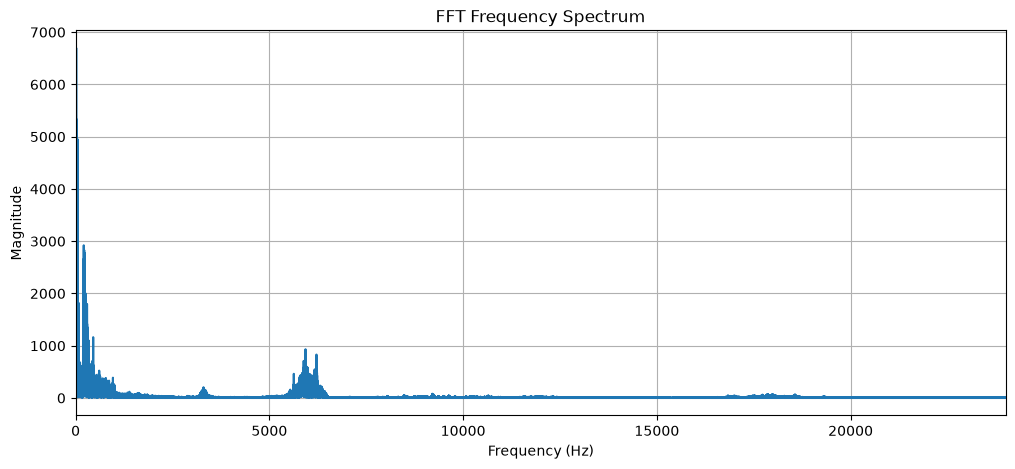

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    positive_freqs,
    positive_magnitude
)

plt.title("FFT Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.xlim(0, sample_rate / 2)

plt.grid(True)
plt.show()

In [20]:
dominant_index = np.argmax(
    positive_magnitude
)

dominant_frequency = positive_freqs[
    dominant_index
]

print(
    f"Dominant frequency: {dominant_frequency:.2f} Hz"
)

Dominant frequency: 15.77 Hz


In [21]:
spectral_centroid = librosa.feature.spectral_centroid(
    y=y_audio,
    sr=sample_rate
)

centroid_values = spectral_centroid.flatten()

print(
    "Mean Spectral Centroid:",
    np.mean(centroid_values)
)

Mean Spectral Centroid: 4043.606949263003


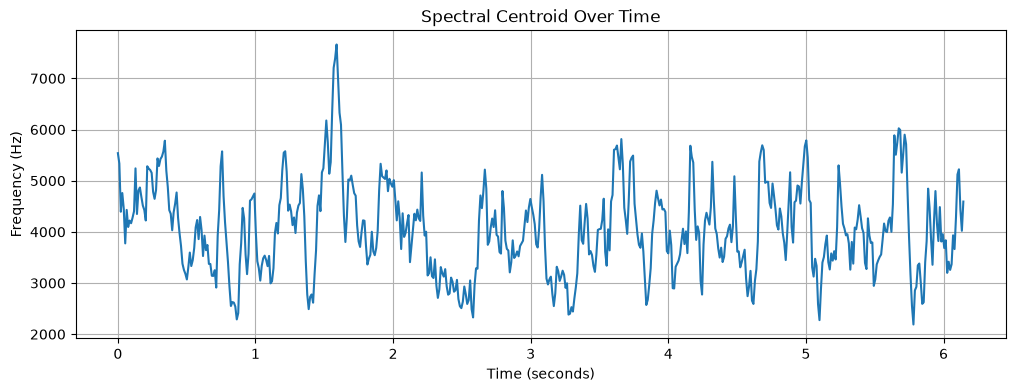

In [22]:
times = librosa.frames_to_time(
    np.arange(len(centroid_values)),
    sr=sample_rate
)

plt.figure(figsize=(12, 4))

plt.plot(
    times,
    centroid_values
)

plt.title("Spectral Centroid Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.grid(True)
plt.show()

In [23]:
spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y_audio,
    sr=sample_rate
)

bandwidth_values = spectral_bandwidth.flatten()

print(
    "Mean Spectral Bandwidth:",
    np.mean(bandwidth_values)
)

Mean Spectral Bandwidth: 5325.2913981090705


In [24]:
spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y_audio,
    sr=sample_rate
)

rolloff_values = spectral_rolloff.flatten()

print(
    "Mean Spectral Rolloff:",
    np.mean(rolloff_values)
)

Mean Spectral Rolloff: 7604.432950606586


In [25]:
frequency_features = {
    "spectral_centroid_mean": np.mean(centroid_values),
    "spectral_centroid_std": np.std(centroid_values),

    "spectral_bandwidth_mean": np.mean(bandwidth_values),
    "spectral_bandwidth_std": np.std(bandwidth_values),

    "spectral_rolloff_mean": np.mean(rolloff_values),
    "spectral_rolloff_std": np.std(rolloff_values)
}

frequency_features

{'spectral_centroid_mean': np.float64(4043.606949263003),
 'spectral_centroid_std': np.float64(877.3420257734923),
 'spectral_bandwidth_mean': np.float64(5325.2913981090705),
 'spectral_bandwidth_std': np.float64(438.4400643572568),
 'spectral_rolloff_mean': np.float64(7604.432950606586),
 'spectral_rolloff_std': np.float64(2025.5201842713368)}

In [26]:
n_fft = 2048
hop_length = 512

stft = librosa.stft(
    y_audio,
    n_fft=n_fft,
    hop_length=hop_length
)

print("STFT shape:", stft.shape)

STFT shape: (1025, 577)


In [27]:
stft_magnitude = np.abs(stft)

print("STFT magnitude shape:", stft_magnitude.shape)

STFT magnitude shape: (1025, 577)


In [28]:
stft_db = librosa.amplitude_to_db(
    stft_magnitude,
    ref=np.max
)

print("STFT dB shape:", stft_db.shape)

STFT dB shape: (1025, 577)


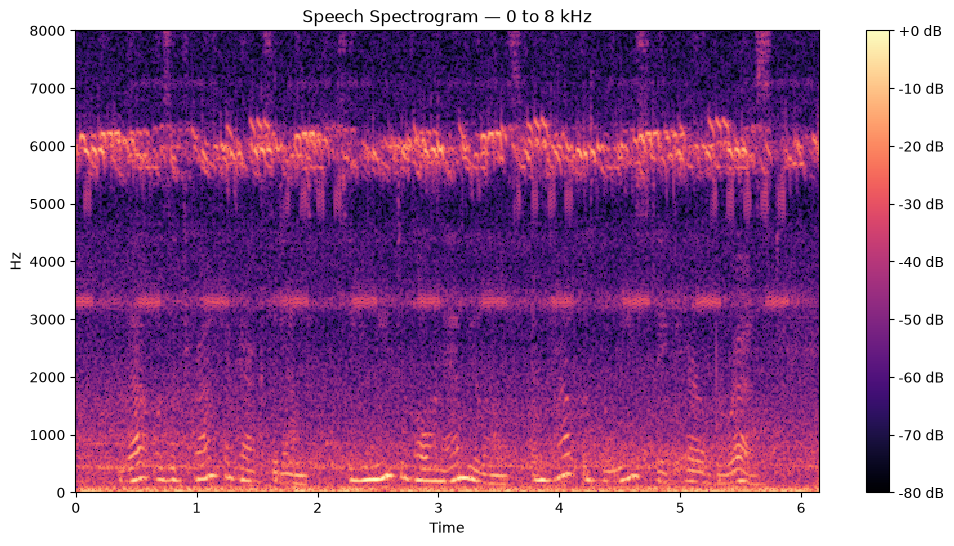

In [31]:
plt.figure(figsize=(12, 6))

librosa.display.specshow(
    stft_db,
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.ylim(0, min(8000, sample_rate / 2))

plt.title("Speech Spectrogram — 0 to 8 kHz")

plt.show()

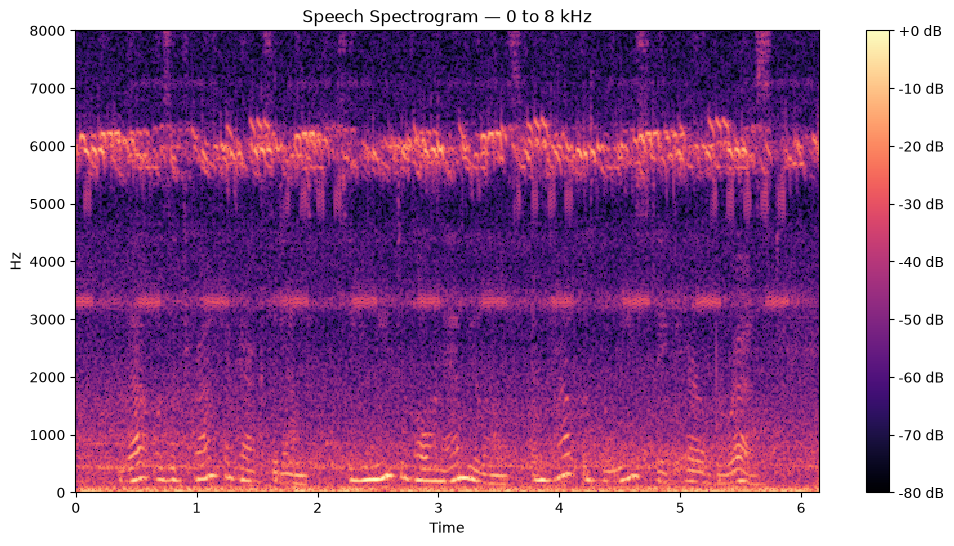

In [30]:
plt.figure(figsize=(12, 6))

librosa.display.specshow(
    stft_db,
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.ylim(0, min(8000, sample_rate / 2))

plt.title("Speech Spectrogram — 0 to 8 kHz")

plt.show()

In [32]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=y_audio,
    sr=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=128
)

print(
    "Mel spectrogram shape:",
    mel_spectrogram.shape
)

Mel spectrogram shape: (128, 577)


In [33]:
mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Mel dB shape:", mel_db.shape)

Mel dB shape: (128, 577)


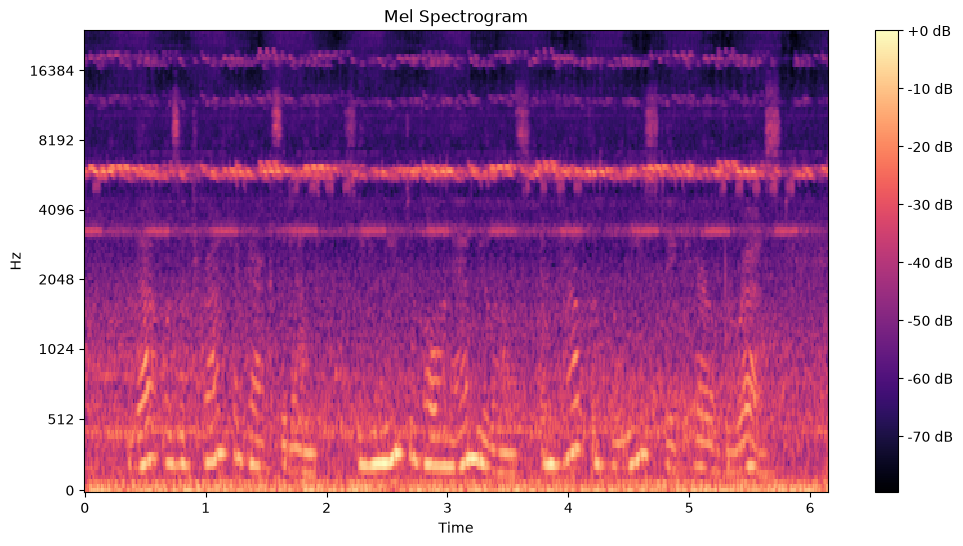

In [34]:
plt.figure(figsize=(12, 6))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title("Mel Spectrogram")

plt.show()

In [35]:
mfcc = librosa.feature.mfcc(
    y=y_audio,
    sr=sample_rate,
    n_mfcc=13,
    n_fft=n_fft,
    hop_length=hop_length
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 577)


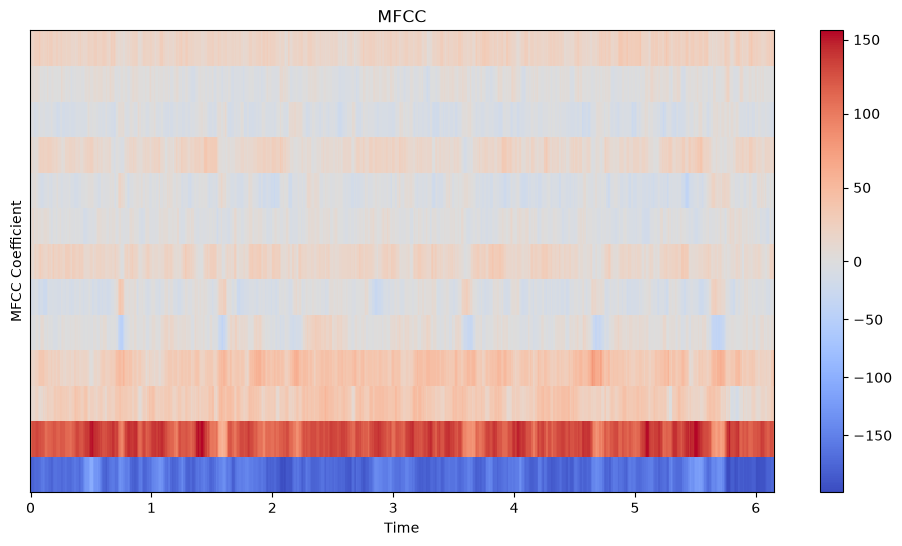

In [36]:
plt.figure(figsize=(12, 6))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate,
    hop_length=hop_length
)

plt.colorbar()

plt.title("MFCC")

plt.ylabel("MFCC Coefficient")

plt.show()

In [37]:
mfcc_features = {}

for i in range(mfcc.shape[0]):
    mfcc_features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
    mfcc_features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

print("Number of MFCC features:", len(mfcc_features))

Number of MFCC features: 26


In [38]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    y_audio,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7"),
    sr=sample_rate
)

print("Pitch array shape:", f0.shape)

Pitch array shape: (577,)


In [39]:
valid_pitch = f0[~np.isnan(f0)]

print("Total pitch frames:", len(f0))
print("Valid pitch frames:", len(valid_pitch))

Total pitch frames: 577
Valid pitch frames: 232


In [40]:
pitch_features = {
    "pitch_mean": np.mean(valid_pitch),
    "pitch_std": np.std(valid_pitch),
    "pitch_min": np.min(valid_pitch),
    "pitch_max": np.max(valid_pitch),
    "pitch_median": np.median(valid_pitch)
}

pitch_features

{'pitch_mean': np.float64(1331.0820940840586),
 'pitch_std': np.float64(860.9069283070863),
 'pitch_min': np.float64(190.41804342135148),
 'pitch_max': np.float64(2068.9643150591514),
 'pitch_median': np.float64(1964.1549710291927)}

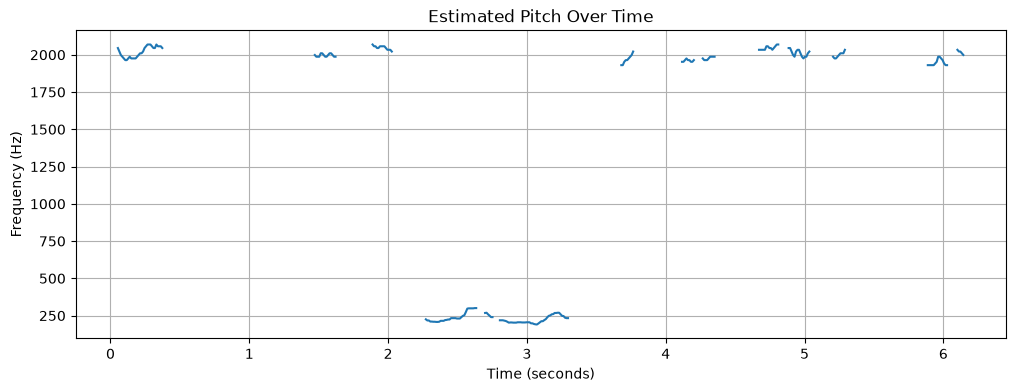

In [41]:
pitch_times = librosa.times_like(
    f0,
    sr=sample_rate
)

plt.figure(figsize=(12, 4))

plt.plot(
    pitch_times,
    f0
)

plt.title("Estimated Pitch Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.grid(True)
plt.show()

In [42]:
all_features = {
    **time_domain_features,
    **frequency_features,
    **mfcc_features,
    **pitch_features
}

print("Total number of features:", len(all_features))

Total number of features: 47


In [43]:
feature_df = pd.DataFrame(
    [all_features]
)

feature_df.T

,0
rms_mean,0.171936
rms_std,0.063151
rms_min,0.057731
rms_max,0.449572
rms_median,0.154696
zcr_mean,0.100178
zcr_std,0.050819
zcr_min,0.014160
zcr_max,0.236816
zcr_median,0.094238


In [44]:
feature_df["mos"] = sample["mos"]

feature_df.T

,0
rms_mean,0.171936
rms_std,0.063151
rms_min,0.057731
rms_max,0.449572
rms_median,0.154696
zcr_mean,0.100178
zcr_std,0.050819
zcr_min,0.014160
zcr_max,0.236816
zcr_median,0.094238



In this notebook we learned how to transform raw speech audio
into meaningful acoustic representations.

## Time Domain

- Waveform
- RMS Energy
- Zero Crossing Rate

## Frequency Domain

- FFT
- Magnitude Spectrum
- Dominant Frequency
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff

## Time-Frequency Domain

- STFT
- Spectrogram

## Perceptual Representation

- Mel Spectrogram

## Speech Representation

- MFCC
- Pitch

These features will later become inputs to our machine-learning models.

The target variable for VoiceIQ is:

Human MOS

Therefore:

X = acoustic features

y = human MOS

We will NOT use existing quality metrics such as PESQ, UTMOS,
NISQA, DNSMOS, SIGMOS, etc. as primary input features.

Those metrics may be used later for benchmarking and analysis.
